# Feature Engineering
## Museum Visitor Prediction — Melbourne Museum of Migration

Based on EDA insights, we build richer features to improve model performance:
- Cyclical encoding for temporal features
- Interaction features
- Additional lag / rolling window features
- Log-transform of target
- Final feature selection

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/museum_visitors_melbourne.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 1096 rows, 26 columns


## 1. Cyclical Encoding of Temporal Features

Day-of-week and month are cyclical (Sunday is close to Monday; December is close to January).  
Using sin/cos transforms preserves this circular distance for tree-based and linear models alike.

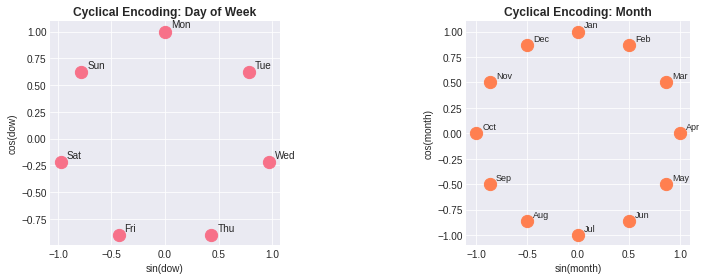

Cyclical features created.


In [14]:
# Day of week: 0-6 -> cyclical
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Month: 1-12 -> cyclical
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# Day of year: 1-365 -> cyclical
df['doy'] = df['date'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365)

# Week of year: cyclical
df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# Visualise cyclical encoding for day of week
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sample = df.drop_duplicates('day_of_week').sort_values('day_of_week')
axes[0].scatter(sample['dow_sin'], sample['dow_cos'], s=150, zorder=5)
for _, row in sample.iterrows():
    axes[0].annotate(day_names[int(row['day_of_week'])],
                     (row['dow_sin'], row['dow_cos']),
                     textcoords='offset points', xytext=(6, 4), fontsize=10)
axes[0].set_title('Cyclical Encoding: Day of Week', fontweight='bold')
axes[0].set_xlabel('sin(dow)')
axes[0].set_ylabel('cos(dow)')
axes[0].set_aspect('equal')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sample_m = df.drop_duplicates('month').sort_values('month')
axes[1].scatter(sample_m['month_sin'], sample_m['month_cos'], s=150, zorder=5, color='coral')
for _, row in sample_m.iterrows():
    axes[1].annotate(month_names[int(row['month']) - 1],
                     (row['month_sin'], row['month_cos']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_title('Cyclical Encoding: Month', fontweight='bold')
axes[1].set_xlabel('sin(month)')
axes[1].set_ylabel('cos(month)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
print("Cyclical features created.")

## 2. Binary / Categorical Features

In [15]:
# Weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Season (Southern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]: return 'Summer'
    elif month in [3, 4, 5]: return 'Autumn'
    elif month in [6, 7, 8]: return 'Winter'
    else: return 'Spring'

df['season'] = df['month'].apply(get_season)
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=False)
df = pd.concat([df, season_dummies], axis=1)

# Weather type encoding
df['weather_encoded'] = df['weather_type'].map(
    {'Sunny': 3, 'Partly Cloudy': 2, 'Cloudy': 1, 'Rainy': 0}
)
weather_dummies = pd.get_dummies(df['weather_type'], prefix='weather', drop_first=False)
df = pd.concat([df, weather_dummies], axis=1)

# Days since project start (long-term trend)
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

print("Binary/categorical features created:")
print(f"  is_weekend, season (4 dummies), weather (4 dummies), days_since_start")
print(f"\nSeason distribution:\n{df['season'].value_counts()}")

Binary/categorical features created:
  is_weekend, season (4 dummies), weather (4 dummies), days_since_start

Season distribution:
Autumn    276
Winter    276
Spring    273
Summer    271
Name: season, dtype: int64


## 3. Interaction Features

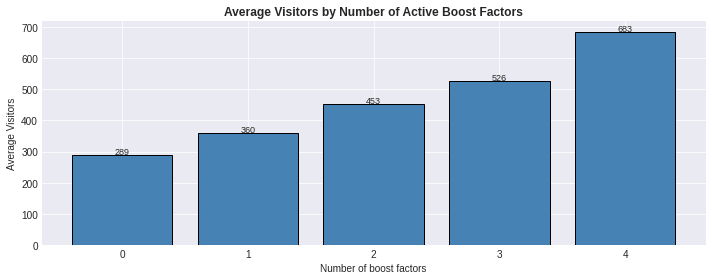

Interaction features created.


In [16]:
# Weekend x holiday (very high impact combo)
df['weekend_x_public_holiday'] = df['is_weekend'] * df['is_public_holiday']
df['weekend_x_school_holiday'] = df['is_weekend'] * df['is_school_holiday']

# Exhibition x weekend (exhibitions drive more weekend visits)
df['exhibition_x_weekend'] = df['special_exhibition'] * df['is_weekend']

# Good weather x weekend (sunny weekends are peak days)
df['sunny_weekend'] = ((df['weather_type'] == 'Sunny') & (df['is_weekend'] == 1)).astype(int)

# Marketing x exhibition (double boost)
df['marketing_x_exhibition'] = df['marketing_campaign'] * df['special_exhibition']

# Any boost day (at least one positive factor active)
df['any_boost'] = (
    (df['is_public_holiday'] == 1) |
    (df['is_school_holiday'] == 1) |
    (df['special_exhibition'] == 1) |
    (df['local_event'] == 1) |
    (df['marketing_campaign'] == 1)
).astype(int)

# Count of active boost factors
df['boost_count'] = (
    df['is_public_holiday'] +
    df['is_school_holiday'] +
    df['special_exhibition'] +
    df['local_event'] +
    df['marketing_campaign'] +
    df['ticket_promotion']
)

# Visualise boost_count vs visitors
plt.figure(figsize=(10, 4))
boost_avg = df.groupby('boost_count')['visitors'].mean()
plt.bar(boost_avg.index, boost_avg, color='steelblue', edgecolor='black')
for x, y in boost_avg.items():
    plt.text(x, y + 3, f'{y:.0f}', ha='center', fontsize=9)
plt.title('Average Visitors by Number of Active Boost Factors', fontweight='bold')
plt.xlabel('Number of boost factors')
plt.ylabel('Average Visitors')
plt.tight_layout()
plt.show()

print("Interaction features created.")

## 4. Extended Lag & Rolling Window Features

In [17]:
# Additional lags
for lag in [1, 2, 3, 14, 21, 28, 60, 90]:
    df[f'visitors_lag_{lag}'] = df['visitors'].shift(lag)

# Rolling statistics
for window in [3, 7, 14, 30, 60, 90]:
    df[f'rolling_mean_{window}d'] = df['visitors'].shift(1).rolling(window).mean()
    df[f'rolling_std_{window}d']  = df['visitors'].shift(1).rolling(window).std()
    df[f'rolling_max_{window}d']  = df['visitors'].shift(1).rolling(window).max()
    df[f'rolling_min_{window}d']  = df['visitors'].shift(1).rolling(window).min()

# Exponentially weighted moving average (more weight on recent days)
df['ewma_7d']  = df['visitors'].shift(1).ewm(span=7,  adjust=False).mean()
df['ewma_14d'] = df['visitors'].shift(1).ewm(span=14, adjust=False).mean()
df['ewma_30d'] = df['visitors'].shift(1).ewm(span=30, adjust=False).mean()

# Same weekday last 4 weeks (capture day-of-week patterns)
df['lag_7_same_dow']  = df['visitors'].shift(7)
df['lag_14_same_dow'] = df['visitors'].shift(14)
df['lag_21_same_dow'] = df['visitors'].shift(21)
df['lag_28_same_dow'] = df['visitors'].shift(28)
df['mean_last_4_same_dow'] = df[['lag_7_same_dow','lag_14_same_dow',
                                  'lag_21_same_dow','lag_28_same_dow']].mean(axis=1)

print(f"Dataset now has {df.shape[1]} columns.")
print("\nNew lag/rolling features added.")

Dataset now has 94 columns.

New lag/rolling features added.


## 5. Log-Transform of Target Variable

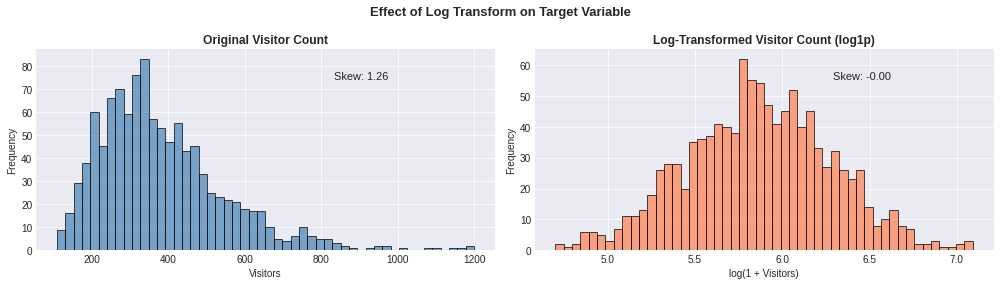

In [18]:
df['visitors_log'] = np.log1p(df['visitors'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['visitors'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Original Visitor Count', fontweight='bold')
axes[0].set_xlabel('Visitors')
axes[0].set_ylabel('Frequency')
axes[0].text(0.65, 0.85, f"Skew: {df['visitors'].skew():.2f}",
             transform=axes[0].transAxes, fontsize=11)

axes[1].hist(df['visitors_log'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Log-Transformed Visitor Count (log1p)', fontweight='bold')
axes[1].set_xlabel('log(1 + Visitors)')
axes[1].set_ylabel('Frequency')
axes[1].text(0.65, 0.85, f"Skew: {df['visitors_log'].skew():.2f}",
             transform=axes[1].transAxes, fontsize=11)

plt.suptitle('Effect of Log Transform on Target Variable', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Drop Early Rows with NaN Lags & Final Cleanup

In [19]:
rows_before = len(df)

# The longest lag is 90 days; drop those rows
df = df.dropna(subset=['visitors_lag_90', 'rolling_mean_90d']).reset_index(drop=True)

print(f"Dropped {rows_before - len(df)} rows with NaN lags.")
print(f"Remaining: {len(df)} rows")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

# Verify no NaNs remain in key columns
remaining_nans = df.isnull().sum()
remaining_nans = remaining_nans[remaining_nans > 0]
if len(remaining_nans) == 0:
    print("No remaining NaN values.")
else:
    print(f"\nColumns still with NaN:\n{remaining_nans}")

Dropped 90 rows with NaN lags.
Remaining: 1006 rows
Date range: 2023-04-01 to 2025-12-31
No remaining NaN values.


## 7. Final Feature Set

In [20]:
# Define the feature groups
temporal_features = [
    'day_of_week', 'month', 'quarter', 'week_of_year', 'doy', 'days_since_start',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'woy_sin', 'woy_cos', 'is_weekend'
]

calendar_features = [
    'is_public_holiday', 'is_school_holiday'
]

event_features = [
    'special_exhibition', 'local_event', 'marketing_campaign',
    'ticket_promotion', 'ticket_price'
]

weather_features = [
    'temperature', 'precipitation', 'weather_encoded',
    'weather_Sunny', 'weather_Partly Cloudy', 'weather_Cloudy', 'weather_Rainy'
]

season_features = ['season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter']

interaction_features = [
    'weekend_x_public_holiday', 'weekend_x_school_holiday',
    'exhibition_x_weekend', 'sunny_weekend',
    'marketing_x_exhibition', 'any_boost', 'boost_count'
]

lag_features = (
    [f'visitors_lag_{l}' for l in [1, 2, 3, 7, 14, 21, 28, 60, 90]] +
    ['visitors_last_week', 'visitors_last_2weeks', 'visitors_last_month', 'visitors_same_day_last_year'] +
    ['mean_last_4_same_dow']
)

rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30, 60, 90]] +
    [f'rolling_std_{w}d'  for w in [3, 7, 14, 30, 60, 90]] +
    [f'rolling_max_{w}d'  for w in [3, 7, 14, 30, 60, 90]] +
    [f'rolling_min_{w}d'  for w in [3, 7, 14, 30, 60, 90]] +
    ['ewma_7d', 'ewma_14d', 'ewma_30d']
)

all_features = (
    temporal_features + calendar_features + event_features +
    weather_features + season_features + interaction_features +
    lag_features + rolling_features
)

# Targets
target_raw = 'visitors'
target_log = 'visitors_log'

print(f"Total features: {len(all_features)}")
print(f"\nFeature groups:")
print(f"  Temporal     : {len(temporal_features)}")
print(f"  Calendar     : {len(calendar_features)}")
print(f"  Events       : {len(event_features)}")
print(f"  Weather      : {len(weather_features)}")
print(f"  Season       : {len(season_features)}")
print(f"  Interaction  : {len(interaction_features)}")
print(f"  Lag          : {len(lag_features)}")
print(f"  Rolling      : {len(rolling_features)}")

Total features: 81

Feature groups:
  Temporal     : 15
  Calendar     : 2
  Events       : 5
  Weather      : 7
  Season       : 4
  Interaction  : 7
  Lag          : 14
  Rolling      : 27


## 8. Feature Correlation with Target

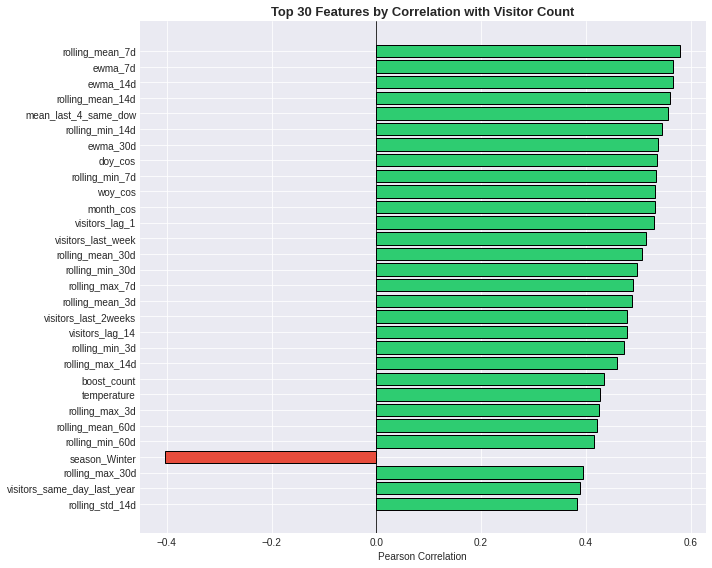

Top 15 most correlated features:
rolling_mean_7d         0.580
ewma_7d                 0.567
ewma_14d                0.566
rolling_mean_14d        0.561
mean_last_4_same_dow    0.557
rolling_min_14d         0.546
ewma_30d                0.538
doy_cos                 0.536
rolling_min_7d          0.535
woy_cos                 0.533
month_cos               0.532
visitors_lag_1          0.530
visitors_last_week      0.515
rolling_mean_30d        0.508
rolling_min_30d         0.498


In [21]:
# Correlation of all features with target
available_features = [f for f in all_features if f in df.columns]
corr_with_target = df[available_features + [target_raw]].corr()[target_raw].drop(target_raw)
corr_sorted = corr_with_target.sort_values(key=abs, ascending=False)

# Plot top 30
top30 = corr_sorted.head(30)
plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top30.values]
plt.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 30 Features by Correlation with Visitor Count', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top 15 most correlated features:")
print(corr_sorted.head(15).round(3).to_string())

## 9. Save Processed Dataset

In [22]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save full engineered dataset
output_path = '../data/processed/museum_visitors_engineered.csv'
df.to_csv(output_path, index=False)

# Save feature list for use in modelling notebook
feature_meta = {
    'temporal': temporal_features,
    'calendar': calendar_features,
    'event': event_features,
    'weather': weather_features,
    'season': season_features,
    'interaction': interaction_features,
    'lag': lag_features,
    'rolling': rolling_features,
    'all': all_features,
    'target_raw': target_raw,
    'target_log': target_log,
}

import json
with open('../data/processed/feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)

print(f"Saved engineered dataset  : {output_path}")
print(f"Saved feature metadata    : ../data/processed/feature_meta.json")
print(f"\nFinal shape: {df.shape}")

Saved engineered dataset  : ../data/processed/museum_visitors_engineered.csv
Saved feature metadata    : ../data/processed/feature_meta.json

Final shape: (1006, 95)


## 10. Summary

In [23]:
print("=" * 55)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"""
Input columns  : {df.shape[1]}
Total features : {len(all_features)}
Training rows  : {len(df)} (after dropping 90-day NaN warmup)

KEY ADDITIONS
  - Cyclical sin/cos for day-of-week, month, day-of-year, week-of-year
  - Season and weather one-hot dummies
  - 7 interaction features (weekend x holiday, sunny weekend, boost_count, etc.)
  - 9 additional lag features (1,2,3,14,21,28,60,90 days + same-weekday avg)
  - 27 rolling features (mean/std/max/min over 3,7,14,30,60,90 days + 3 EWMA)
  - Log1p transform of target (visitors_log)

OUTPUTS
  data/processed/museum_visitors_engineered.csv
  data/processed/feature_meta.json
""")
print("=" * 55)

FEATURE ENGINEERING SUMMARY

Input columns  : 95
Total features : 81
Training rows  : 1006 (after dropping 90-day NaN warmup)

KEY ADDITIONS
  - Cyclical sin/cos for day-of-week, month, day-of-year, week-of-year
  - Season and weather one-hot dummies
  - 7 interaction features (weekend x holiday, sunny weekend, boost_count, etc.)
  - 9 additional lag features (1,2,3,14,21,28,60,90 days + same-weekday avg)
  - 27 rolling features (mean/std/max/min over 3,7,14,30,60,90 days + 3 EWMA)
  - Log1p transform of target (visitors_log)

OUTPUTS
  data/processed/museum_visitors_engineered.csv
  data/processed/feature_meta.json



## Next Step

**`04_modeling.ipynb`** — Train and compare ML models:
- Baseline (mean, last-week)
- Random Forest
- XGBoost
- Prophet (time series)
- Cross-validated evaluation with time-series split